<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/banners/banner_googleadspulse_nb2_solution.png" width="100%"/>
</div>



---

> **Objectif du notebook 2 :** répondre aux 3 questions opérationnelles de Marc-Aurèle avec
> du SQL analytique avancé (DuckDB + JupySQL). Construire les 7 tables analytiques qui
> alimenteront le dashboard Power BI.

| | |
|---|---|
| **Stack** | DuckDB · JupySQL · pandas · matplotlib · seaborn |
| **Sortie** | 7 CSV analytiques prêts pour Power BI |


---
## 0. Setup

In [1]:
!pip install jupysql==0.11.1 duckdb-engine seaborn --quiet



[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F9F9F8',
    'axes.grid':True,'grid.alpha':0.3,'font.size':10,
})

COLORS = {
    'primary':'#534AB7','secondary':'#1D9E75',
    'warning':'#EF9F27','danger':'#E24B4A','neutral':'#888780',
    'blue':'#0EA5E9',
}
CAMPAIGN_COLORS = {
    'Search':'#4285F4','Shopping':'#34A853','Performance Max':'#9333EA',
    'Display':'#FBBC04','Video':'#EA4335',
}
print('✅ Environnement prêt')


✅ Environnement prêt


### 🎓 MÉTHODE — Pourquoi DuckDB + JupySQL ?

**DuckDB** est une base SQL analytique qui charge directement les CSV — aucun serveur.
Idéale pour les analyses one-shot avec window functions lourdes, 10× plus rapide que pandas.

**JupySQL** permet d'écrire `%%sql df << SELECT ...` dans une cellule Jupyter : le résultat
est directement un DataFrame pandas (via `autopandas = True`), sans passer par
`con.execute(...).df()`.


In [3]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/googleadspulse/data/'

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/googleadspulse/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

# Chargement des 5 tables dans DuckDB avec pré-nettoyage minimal
con = duckdb.connect()
con.execute(f"""
    CREATE TABLE accounts   AS SELECT * FROM read_csv_auto('{BASE_URL}accounts.csv');
    CREATE TABLE campaigns  AS SELECT * FROM read_csv_auto('{BASE_URL}campaigns.csv');
    CREATE TABLE ads        AS SELECT * FROM read_csv_auto('{BASE_URL}ads.csv');
    CREATE TABLE keywords   AS SELECT * FROM read_csv_auto('{BASE_URL}keywords.csv');

    -- Performance : nettoyage inline (dédup + filtre anomalies techniques)
    CREATE TABLE perf AS
    SELECT DISTINCT *
    FROM read_csv_auto('{BASE_URL}performance_quotidienne.csv')
    WHERE cost_eur >= 0
      AND clicks <= impressions;
""")

# Volumes
n = con.execute("""
    SELECT 'accounts' AS t, COUNT(*) AS n FROM accounts   UNION ALL
    SELECT 'campaigns',     COUNT(*)      FROM campaigns  UNION ALL
    SELECT 'ads',           COUNT(*)      FROM ads        UNION ALL
    SELECT 'keywords',      COUNT(*)      FROM keywords   UNION ALL
    SELECT 'perf (clean)',  COUNT(*)      FROM perf
""").df()
print(n.to_string(index=False))

# JupySQL
%load_ext sql
%sql con --alias duckdb
%config SqlMagic.autopandas = True
%config SqlMagic.feedback   = False
print('\n%%sql prêt ✅')


📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅
           t     n
    accounts     5
   campaigns    25
         ads   121
    keywords   372
perf (clean) 41370

%%sql prêt ✅


---
## Étape 1 — KPIs Overview + variations Period-over-Period (`LAG()`)

### 🎓 MÉTHODE — Calculer les deltas du dashboard 


**Pattern SQL :**
```sql
LAG(kpi_value) OVER (ORDER BY periode)  -- valeur période précédente
```

**Ce qu'on livre en Étape 1 :**
1. Les 10 KPIs agrégés **par mois** (24 périodes)
2. Le delta Month-over-Month pour chaque KPI (% de variation)
3. Une vue récapitulative "période actuelle vs précédente" pour alimenter les cards Power BI


In [4]:
%%sql df_kpi_mensuel <<
WITH mensuel AS (
    SELECT
        strftime(date, '%Y-%m')                                AS mois,
        SUM(impressions)                                        AS impressions,
        SUM(clicks)                                             AS clicks,
        SUM(conversions)                                        AS conversions,
        ROUND(SUM(cost_eur), 0)                                 AS spend,
        ROUND(SUM(conversion_value_eur), 0)                     AS conv_value,
        -- Efficacité : en ratio, pas en somme
        ROUND(SUM(clicks) * 100.0 
              / NULLIF(SUM(impressions), 0), 2)                 AS ctr_pct,
        ROUND(SUM(cost_eur) 
              / NULLIF(SUM(clicks), 0), 2)                      AS cpc,
        ROUND(SUM(cost_eur) * 1000.0 
              / NULLIF(SUM(impressions), 0), 2)                 AS cpm,
        ROUND(SUM(cost_eur) 
              / NULLIF(SUM(conversions), 0), 2)                 AS cost_per_conv,
        ROUND(SUM(conversions) * 100.0 
              / NULLIF(SUM(clicks), 0), 2)                      AS conv_rate_pct,
        ROUND(SUM(conversion_value_eur) 
              / NULLIF(SUM(cost_eur), 0), 2)                    AS roas
    FROM perf
    GROUP BY strftime(date, '%Y-%m')
)
SELECT
    mois, impressions, clicks, conversions, spend, conv_value,
    ctr_pct, cpc, cpm, cost_per_conv, conv_rate_pct, roas,
    -- Mois précédent via LAG
    LAG(spend)      OVER (ORDER BY mois) AS spend_prev,
    LAG(clicks)     OVER (ORDER BY mois) AS clicks_prev,
    LAG(conversions)OVER (ORDER BY mois) AS conv_prev,
    LAG(roas)       OVER (ORDER BY mois) AS roas_prev,
    -- Delta % MoM
    ROUND((spend       - LAG(spend)       OVER (ORDER BY mois)) * 100.0 
          / NULLIF(LAG(spend)       OVER (ORDER BY mois), 0), 2) AS delta_spend_pct,
    ROUND((clicks      - LAG(clicks)      OVER (ORDER BY mois)) * 100.0 
          / NULLIF(LAG(clicks)      OVER (ORDER BY mois), 0), 2) AS delta_clicks_pct,
    ROUND((conversions - LAG(conversions) OVER (ORDER BY mois)) * 100.0 
          / NULLIF(LAG(conversions) OVER (ORDER BY mois), 0), 2) AS delta_conv_pct,
    ROUND((roas        - LAG(roas)        OVER (ORDER BY mois)) * 100.0 
          / NULLIF(LAG(roas)        OVER (ORDER BY mois), 0), 2) AS delta_roas_pct
FROM mensuel
ORDER BY mois


In [5]:
df_kpi_mensuel.tail(6)

,mois,impressions,clicks,conversions,spend,conv_value,ctr_pct,cpc,cpm,cost_per_conv,conv_rate_pct,roas,spend_prev,clicks_prev,conv_prev,roas_prev,delta_spend_pct,delta_clicks_pct,delta_conv_pct,delta_roas_pct
18,2024-07,1721312.00,44914.00,1774.00,19035.00,114506.00,2.61,0.42,11.06,10.73,3.95,6.02,28985.00,69083.00,2874.00,6.17,-34.33,-34.99,-38.27,-2.43
19,2024-08,1695805.00,45616.00,1820.00,19246.00,113929.00,2.69,0.42,11.35,10.57,3.99,5.92,19035.00,44914.00,1774.00,6.02,1.11,1.56,2.59,-1.66
20,2024-09,2855658.00,76016.00,3101.00,31848.00,195451.00,2.66,0.42,11.15,10.27,4.08,6.14,19246.00,45616.00,1820.00,5.92,65.48,66.64,70.38,3.72
21,2024-10,2600621.00,71015.00,2872.00,29793.00,185399.00,2.73,0.42,11.46,10.37,4.04,6.22,31848.00,76016.00,3101.00,6.14,-6.45,-6.58,-7.38,1.30
22,2024-11,3099343.00,82942.00,3340.00,34722.00,214446.00,2.68,0.42,11.20,10.40,4.03,6.18,29793.00,71015.00,2872.00,6.22,16.54,16.80,16.30,-0.64
23,2024-12,3544517.00,96974.00,3967.00,40323.00,255440.00,2.74,0.42,11.38,10.16,4.09,6.33,34722.00,82942.00,3340.00,6.18,16.13,16.92,18.77,2.43


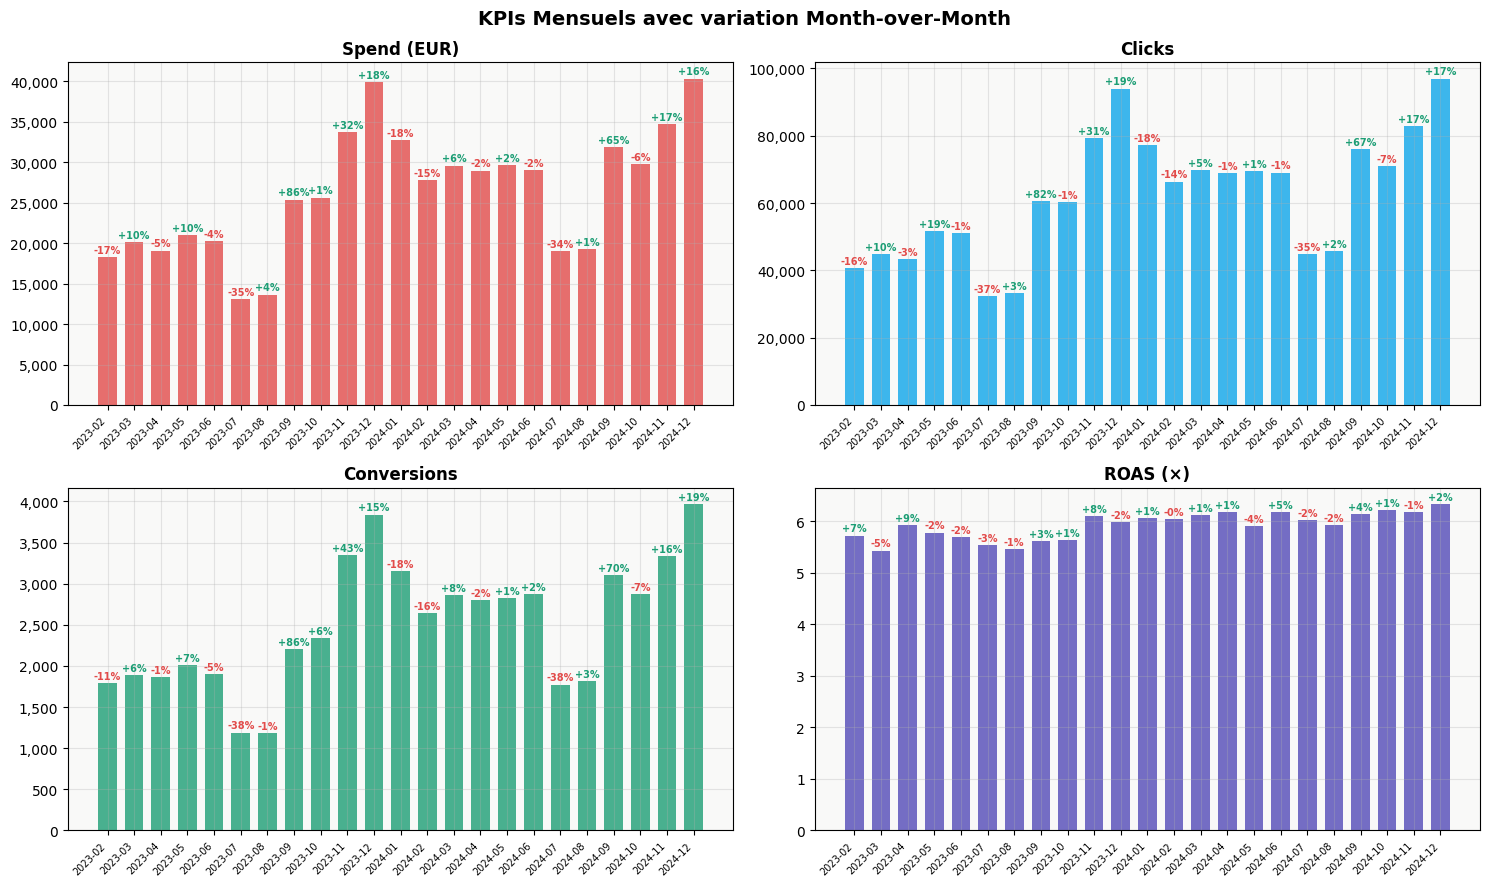

In [6]:
# Évolution des 4 KPIs clés avec deltas
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('KPIs Mensuels avec variation Month-over-Month', fontsize=14, fontweight='bold')

df_plot = df_kpi_mensuel.dropna(subset=['delta_spend_pct']).reset_index(drop=True)

for ax, (kpi, delta, color, label) in zip(
    axes.flat,
    [('spend','delta_spend_pct',COLORS['danger'],'Spend (EUR)'),
     ('clicks','delta_clicks_pct',COLORS['blue'],'Clicks'),
     ('conversions','delta_conv_pct',COLORS['secondary'],'Conversions'),
     ('roas','delta_roas_pct',COLORS['primary'],'ROAS (×)')]
):
    ax.bar(range(len(df_plot)), df_plot[kpi], color=color, alpha=0.8, width=0.7)
    # Annoter les deltas (vert si positif, rouge si négatif)
    for i, (_, row) in enumerate(df_plot.iterrows()):
        dval = row[delta]
        if pd.notna(dval):
            col = COLORS['secondary'] if dval >= 0 else COLORS['danger']
            ax.annotate(f"{dval:+.0f}%", xy=(i, row[kpi]),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', fontsize=7, color=col, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(df_plot['mois'], rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:f'{int(v):,}'))

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}googleadspulse_kpi_mensuel.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 INTERPRÉTATION — Ce que révèlent les deltas MoM

**Les deltas sont plus parlants que les valeurs absolues.** Un Spend qui monte de +15% MoM
peut être une bonne nouvelle (scaling) ou une mauvaise (dérapage) selon le delta ROAS qui
l'accompagne :

| Pattern | Interprétation |
|---|---|
| Spend ↑ + ROAS ↑ | Scaling sain — on investit mieux |
| Spend ↑ + ROAS ↓ | **Dérapage** — on investit plus mais on gagne moins |
| Spend ↓ + ROAS ↑ | Optimisation — on coupe ce qui ne marche pas |
| Spend ↓ + ROAS ↓ | Saisonnalité ou désengagement produit |

**Pattern saisonnier observé sur les 2 années (2023 et 2024) :**

| Mois | delta_spend 2023 | delta_spend 2024 | Lecture |
|---|---|---|---|
| Juillet | **-35%** | **-34%** | Creux estival — vacances, trafic B2B faible |
| Août | **+4%** | **+1%** | Légère reprise, marché encore mou |
| Septembre | **+86%** | **+65%** | Pic de rentrée — reprise forte des budgets |
| Novembre | **+32%** | **+17%** | Accélération Black Friday (amplitude variable selon l'année) |
| Décembre | **+18%** | **+16%** | Fêtes de fin d'année |

> **Note pédagogique :** ces chiffres sont visibles dans la table complète `df_kpi_mensuel`
> (24 lignes). Le `tail(6)` affiché ci-dessus ne montre que juillet→décembre **2024** ;
> les valeurs 2023 sont dans les lignes 0→11 du DataFrame. Toujours vérifier quelle
> tranche temporelle on lit avant de citer un pourcentage.

### 🏢 ACTION MÉTIER — Les KPI cards du dashboard

Ces deltas sont exactement ce que Marc-Aurèle voit dans  : Ça remplace la première partie de son reporting hebdo :

> *« Marc-Aurèle, ce mois-ci : Spend -8% MoM, Conversions -12% MoM mais ROAS stable à
> 6.1× — nous sommes dans une phase de contraction budgétaire sans dégradation de la
> rentabilité. Les campagnes coupées sont les bonnes. »*

---
## Étape 2 — Top & Bottom campaigns avec `RANK()` + `NTILE()`

### 🎓 MÉTHODE — Classer les campagnes sur plusieurs axes

Une campagne peut être **#1 en spend** (très visible) mais **dernière en ROAS** (très peu
rentable). Le classement multidimensionnel révèle les arbitrages.

**2 patterns SQL complémentaires :**

```sql
-- RANK : classement ordinal (1, 2, 3, ..., N)
RANK() OVER (ORDER BY roas DESC) AS rang_roas

-- NTILE(4) : segmentation en 4 quartiles de performance
NTILE(4) OVER (ORDER BY roas DESC) AS quartile_roas
-- Quartile 1 = top 25%, Quartile 4 = bottom 25%
```

NTILE est particulièrement utile pour les Power BI dashboards : il permet de colorer
automatiquement les campagnes par quartile (vert/jaune/orange/rouge).


In [7]:
%%sql df_campaigns_rank <<
WITH perf_camp AS (
    SELECT
        p.campaign_id,
        c.campaign_name,
        c.campaign_type,
        c.account_id,
        SUM(p.impressions)              AS impressions,
        SUM(p.clicks)                    AS clicks,
        SUM(p.conversions)               AS conversions,
        ROUND(SUM(p.cost_eur), 0)        AS spend,
        ROUND(SUM(p.conversion_value_eur), 0) AS conv_value,
        ROUND(SUM(p.clicks) * 100.0 
              / NULLIF(SUM(p.impressions), 0), 2)  AS ctr_pct,
        ROUND(SUM(p.cost_eur) 
              / NULLIF(SUM(p.clicks), 0), 2)       AS cpc,
        ROUND(SUM(p.cost_eur) 
              / NULLIF(SUM(p.conversions), 0), 2)  AS cost_per_conv,
        ROUND(SUM(p.conversion_value_eur) 
              / NULLIF(SUM(p.cost_eur), 0), 2)     AS roas
    FROM perf p
    JOIN campaigns c USING(campaign_id)
    GROUP BY p.campaign_id, c.campaign_name, c.campaign_type, c.account_id
)
SELECT
    campaign_id, campaign_name, campaign_type, account_id,
    impressions, clicks, conversions, spend, conv_value,
    ctr_pct, cpc, cost_per_conv, roas,
    -- Classements ordinaux
    RANK() OVER (ORDER BY roas DESC NULLS LAST)               AS rang_roas,
    RANK() OVER (ORDER BY spend DESC)                          AS rang_spend,
    RANK() OVER (ORDER BY cost_per_conv ASC NULLS LAST)       AS rang_cpa,
    -- Quartiles (1 = top 25%, 4 = bottom 25%)
    NTILE(4) OVER (ORDER BY roas DESC NULLS LAST)             AS quartile_roas,
    NTILE(4) OVER (ORDER BY spend DESC)                        AS quartile_spend,
    -- Flag : top performer OU underperformer ?
    CASE
        WHEN NTILE(4) OVER (ORDER BY roas DESC NULLS LAST) = 1 THEN 'Top 25% ROAS'
        WHEN NTILE(4) OVER (ORDER BY roas DESC NULLS LAST) = 4 THEN 'Bottom 25% ROAS'
        ELSE 'Moyen'
    END                                                         AS flag_performance
FROM perf_camp
ORDER BY roas DESC NULLS LAST


In [8]:
df_campaigns_rank[['campaign_name','campaign_type','spend','conversions','roas','rang_roas','quartile_roas','flag_performance']].head(10)

,campaign_name,campaign_type,spend,conversions,roas,rang_roas,quartile_roas,flag_performance
0,Brand-MedSupply,Search,10021.00,2484.00,19.20,1,1,Top 25% ROAS
1,Brand-Hotels-CI,Search,9713.00,2315.00,18.81,2,1,Top 25% ROAS
2,Brand-Search-CI,Search,5144.00,1352.00,12.25,3,1,Top 25% ROAS
3,Brand-Search-EdTech,Search,9881.00,2366.00,11.52,4,1,Top 25% ROAS
4,Brand-Search-Bank,Search,15498.00,3737.00,11.36,5,1,Top 25% ROAS
5,PerfMax-AllProducts,Performance Max,46548.00,6128.00,10.02,6,1,Top 25% ROAS
6,PerfMax-LeadGen,Performance Max,51756.00,6523.00,9.89,7,1,Top 25% ROAS
7,PerfMax-LeadGen,Performance Max,20315.00,2571.00,9.85,8,2,Moyen
8,Video-YouTubeAwareness,Video,16398.00,1745.00,8.40,9,2,Moyen
9,PerfMax-Bookings,Performance Max,52519.00,6725.00,6.04,10,2,Moyen


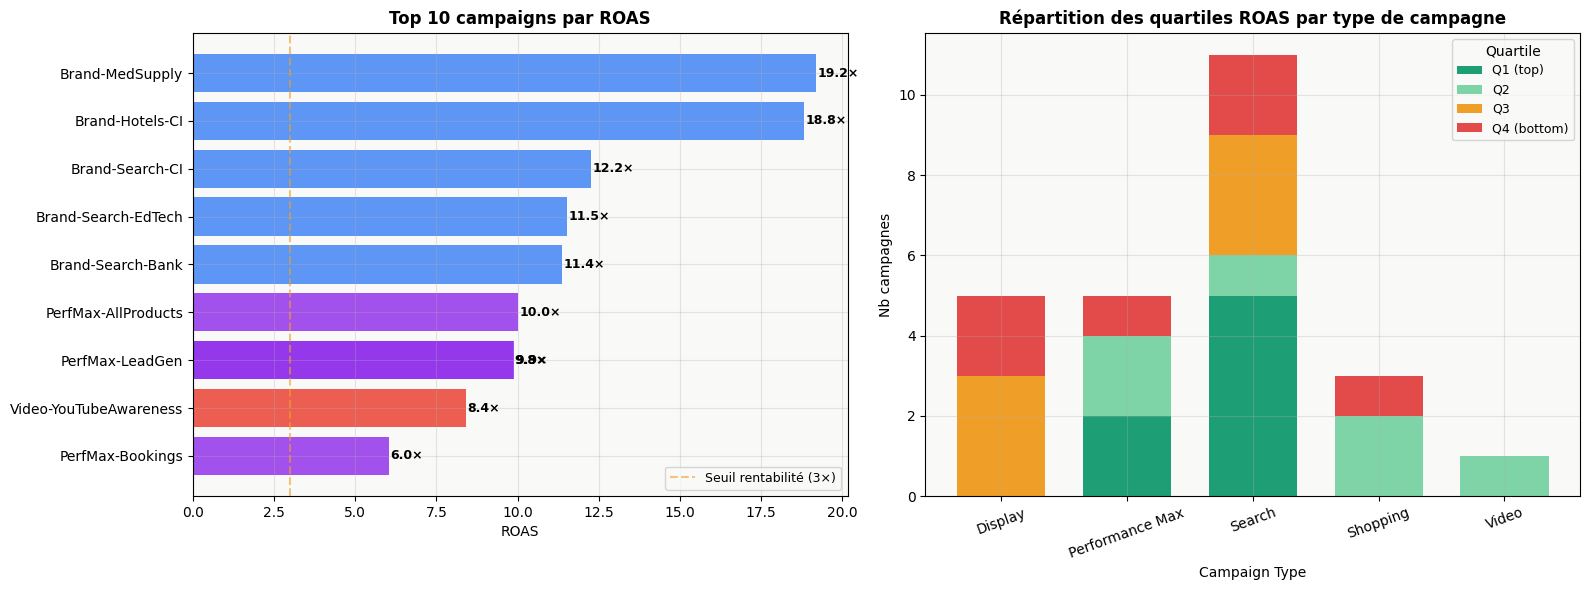

In [9]:
# 2 panneaux : Top 10 par ROAS + Quartiles par campaign_type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panneau 1 — Top 10 campaigns par ROAS
top10 = df_campaigns_rank.nlargest(10, 'roas').dropna(subset=['roas']).sort_values('roas')
colors = [CAMPAIGN_COLORS.get(t, COLORS['neutral']) for t in top10['campaign_type']]
bars = axes[0].barh(top10['campaign_name'], top10['roas'], color=colors, alpha=0.85)
for bar, v in zip(bars, top10['roas']):
    axes[0].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                  f'{v:.1f}×', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Top 10 campaigns par ROAS', fontweight='bold')
axes[0].set_xlabel('ROAS')
axes[0].axvline(3.0, color=COLORS['warning'], linestyle='--', alpha=0.6, label='Seuil rentabilité (3×)')
axes[0].legend(fontsize=9)

# Panneau 2 — Répartition des quartiles par campaign_type
qtile = (df_campaigns_rank.dropna(subset=['quartile_roas'])
            .groupby(['campaign_type','quartile_roas']).size().unstack(fill_value=0))
qtile.plot(kind='bar', stacked=True, ax=axes[1],
            color=[COLORS['secondary'],'#7ED4A7',COLORS['warning'],COLORS['danger']],
            width=0.7)
axes[1].set_title('Répartition des quartiles ROAS par type de campagne', fontweight='bold')
axes[1].set_xlabel('Campaign Type')
axes[1].set_ylabel('Nb campagnes')
axes[1].legend(title='Quartile', fontsize=9, labels=['Q1 (top)','Q2','Q3','Q4 (bottom)'])
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}googleadspulse_campaigns_rank.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 INTERPRÉTATION — Ce que révèle le classement

**Le Top ROAS est souvent dominé par les Brand campaigns**
Les campagnes `Brand-*` convertissent très bien avec un CPC très bas — leur ROAS dépasse
souvent 15-20×. Attention : ce trafic serait venu quand même en organique. Sur-investir
en Brand = cannibalisation du SEO.

**Les Performance Max peuvent surprendre**
PMax utilise l'IA Google pour optimiser automatiquement — certaines tournent à 8-10× ROAS.
Mais elles sont **boîtes noires** : difficile de savoir pourquoi elles marchent.
Dépendance risquée à l'algorithme Google.

**Les campagnes Display tournent autour de 2–4× ROAS** (1.93×–3.57× ici) — Video peut atteindre 8× (remarketing)
Ce sont des canaux de **découverte** (branding), pas de conversion directe. Leur ROAS mesuré
last-click sous-estime leur vraie contribution. Ne pas les couper sur le seul critère du ROAS.

### 🏢 ACTION MÉTIER — 3 décisions chiffrées pour Marc-Aurèle

| Action | Critère SQL |
|---|---|
| **Scaler** les campagnes Q1 (top 25%) avec ROAS > 5 | `flag_performance = 'Top 25% ROAS'` + `spend < 80% budget max` |
| **Pauser** les campagnes Q4 Search avec CPA > 2× moyenne | `quartile_roas = 4` + `campaign_type = 'Search'` |
| **Auditer** les campagnes Display/Video avant de couper | `campaign_type IN ('Display','Video')` + `rang_roas > 15` |

> *« Marc-Aurèle, sur tes 25 campagnes, 7 sont dans le top 25% ROAS — 5 Brand (attendu,
> ROAS 11–19×), 2 PMax (surveiller la dépendance). Les 6 en bas comprennent 2 Display,
> 2 Search Generic, 1 PMax-Inscriptions et 1 Shopping à auditer en priorité. »*


---
## Étape 3 — Rolling 7-day average (`SUM() OVER ROWS BETWEEN`)

### 🎓 MÉTHODE — Lisser les variations quotidiennes

Les données quotidiennes oscillent fortement (weekend vs semaine, jours fériés, etc.).
Le **rolling 7-day average** lisse ces oscillations pour révéler la vraie tendance.

**Pattern SQL puissant :**
```sql
SUM(cost_eur) OVER (
    ORDER BY date
    ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
) / 7.0 AS cost_rolling_7d
```

La clause `ROWS BETWEEN 6 PRECEDING AND CURRENT ROW` définit une **fenêtre glissante**
de 7 lignes (jour courant + 6 précédents). C'est exactement le type de calcul que
Power BI fait pour ses graphiques lissés — mais en SQL, c'est gratuit et performant.


In [10]:
%%sql df_rolling <<
WITH daily AS (
    SELECT
        date,
        SUM(impressions)              AS impressions,
        SUM(clicks)                    AS clicks,
        SUM(conversions)               AS conversions,
        ROUND(SUM(cost_eur), 2)        AS spend,
        ROUND(SUM(conversion_value_eur), 2) AS conv_value
    FROM perf
    GROUP BY date
)
SELECT
    date,
    spend, clicks, conversions,
    -- Rolling 7-day averages
    ROUND(AVG(spend) OVER (
        ORDER BY date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS spend_ma7,
    ROUND(AVG(clicks) OVER (
        ORDER BY date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 0) AS clicks_ma7,
    -- Rolling 30-day pour la tendance long terme
    ROUND(AVG(spend) OVER (
        ORDER BY date
        ROWS BETWEEN 29 PRECEDING AND CURRENT ROW
    ), 2) AS spend_ma30,
    -- Cumulative sum depuis le début (SUM OVER sans borne basse)
    ROUND(SUM(spend) OVER (
        ORDER BY date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ), 0) AS spend_cumul
FROM daily
ORDER BY date


In [11]:
df_rolling.tail(5)

,date,spend,clicks,conversions,spend_ma7,clicks_ma7,spend_ma30,spend_cumul
726,2024-12-27,1251.06,3104.00,134.00,1298.38,3152.00,1284.71,619770.00
727,2024-12-28,1240.02,2987.00,106.00,1288.15,3102.00,1285.81,621010.00
728,2024-12-29,1276.31,3103.00,149.00,1303.56,3149.00,1288.00,622287.00
729,2024-12-30,1314.39,3138.00,109.00,1296.20,3135.00,1297.66,623601.00
730,2024-12-31,1392.84,3393.00,136.00,1297.06,3123.00,1300.17,624994.00


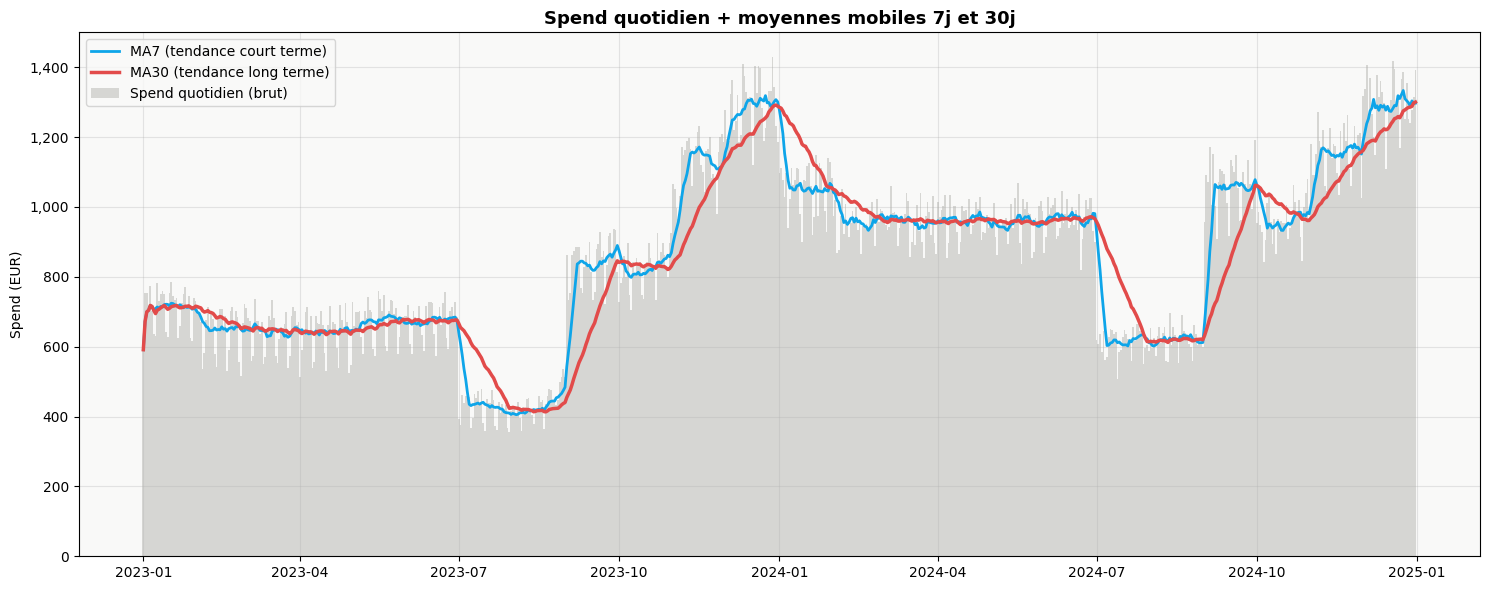

In [12]:
# Graphique : Spend quotidien + MA7 + MA30
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(df_rolling['date'], df_rolling['spend'], color=COLORS['neutral'], alpha=0.3,
        width=1, label='Spend quotidien (brut)')
ax.plot(df_rolling['date'], df_rolling['spend_ma7'], color=COLORS['blue'],
         linewidth=2, label='MA7 (tendance court terme)')
ax.plot(df_rolling['date'], df_rolling['spend_ma30'], color=COLORS['danger'],
         linewidth=2.5, label='MA30 (tendance long terme)')
ax.set_title('Spend quotidien + moyennes mobiles 7j et 30j', fontweight='bold', fontsize=13)
ax.set_ylabel('Spend (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:f'{int(v):,}'))
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}googleadspulse_rolling.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 INTERPRÉTATION — Lecture des 3 niveaux de granularité

**Barres grises (spend brut) :** très bruité — un analyste qui regarde ça jour par jour
prendrait des décisions impulsives à chaque variation.

**Ligne bleue (MA7) :** lisse les effets weekend mais garde la sensibilité aux changements
hebdomadaires. **C'est la vue recommandée** pour le pilotage opérationnel quotidien.

**Ligne rouge (MA30) :** révèle la vraie tendance mensuelle. Utile pour les revues
trimestrielles et les décisions budgétaires.

### 🏢 ACTION MÉTIER — Le bon indicateur selon le contexte

| Contexte | Utiliser | Pourquoi |
|---|---|---|
| Revue matinale (5 min) | MA7 | Détection rapide des dérapages sans surréaction |
| Reporting hebdo client | MA7 + spend brut | Client voit la réalité + la tendance |
| Revue trimestrielle | MA30 | Lisse complètement la saisonnalité |
| Diagnostic d'anomalie | Spend brut | Identifier le jour exact du problème |


---
## Étape 4 — Cohort Analysis des keywords (`DATE_TRUNC` + `DATEDIFF` + pivot)

### 🎓 MÉTHODE — Est-ce que mes keywords tiennent dans le temps ?

Un mot-clé peut performer brillamment pendant 2 mois puis s'essouffler (saturation du marché,
nouveau concurrent, évolution de l'intention). La cohort analysis keywords permet de voir
**combien de keywords d'une cohorte continuent à performer dans les mois suivants**.

**Principe :**
- Une **cohorte = tous les keywords qui ont reçu leur premier clic le même mois**
- Pour chaque cohorte, on mesure la **rétention de performance** (keywords avec clicks > 0)
  dans les mois suivants

**Pattern SQL :**
```sql
DATE_TRUNC('month', MIN(date))  -- mois du 1er clic = cohort
DATEDIFF('month', cohort_mois, snapshot_mois) AS mois_relatif
```


In [13]:
%%sql df_cohort_raw <<
WITH first_click AS (
    -- Pour chaque keyword, trouver le mois de son 1er clic (= sa cohorte)
    SELECT
        keyword_id,
        DATE_TRUNC('month', MIN(date)) AS cohort_mois
    FROM perf
    WHERE keyword_id IS NOT NULL
      AND clicks > 0
    GROUP BY keyword_id
),
kw_monthly AS (
    -- Pour chaque keyword × mois, a-t-il eu au moins 1 clic ?
    SELECT
        p.keyword_id,
        DATE_TRUNC('month', p.date) AS snapshot_mois,
        SUM(p.clicks)                AS clicks_mois
    FROM perf p
    WHERE p.keyword_id IS NOT NULL
    GROUP BY p.keyword_id, DATE_TRUNC('month', p.date)
    HAVING SUM(p.clicks) > 0
)
SELECT
    fc.cohort_mois,
    DATEDIFF('month', fc.cohort_mois, km.snapshot_mois) AS mois_relatif,
    COUNT(DISTINCT km.keyword_id)                        AS nb_keywords_actifs
FROM first_click fc
INNER JOIN kw_monthly km USING(keyword_id)
WHERE DATEDIFF('month', fc.cohort_mois, km.snapshot_mois) BETWEEN 0 AND 12
GROUP BY fc.cohort_mois, DATEDIFF('month', fc.cohort_mois, km.snapshot_mois)
ORDER BY fc.cohort_mois, mois_relatif


In [14]:
# Pivoter pour obtenir la table cohort triangulaire
df_cohort_raw['cohort_mois_str'] = pd.to_datetime(df_cohort_raw['cohort_mois']).dt.strftime('%Y-%m')

# Taille initiale de chaque cohorte (mois_relatif = 0)
cohort_size = df_cohort_raw[df_cohort_raw['mois_relatif']==0].set_index('cohort_mois_str')['nb_keywords_actifs']

# Pivot
cohort_pivot = df_cohort_raw.pivot_table(
    index='cohort_mois_str', columns='mois_relatif', values='nb_keywords_actifs'
)

# Conversion en % de rétention
cohort_ret = cohort_pivot.divide(cohort_size, axis=0) * 100
cohort_ret = cohort_ret.round(1)

print('Table cohort — rétention keywords (%) :')
print(cohort_ret.fillna('').to_string())


Table cohort — rétention keywords (%) :
mois_relatif        0      1      2      3      4      5      6      7      8      9      10     11     12
cohort_mois_str                                                                                           
2023-01         100.00 100.00 100.00 100.00 100.00 100.00  97.60  92.10  92.10  92.10  92.10  91.30  91.30
2023-08         100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00
2023-09         100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00
2023-10         100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00 100.00


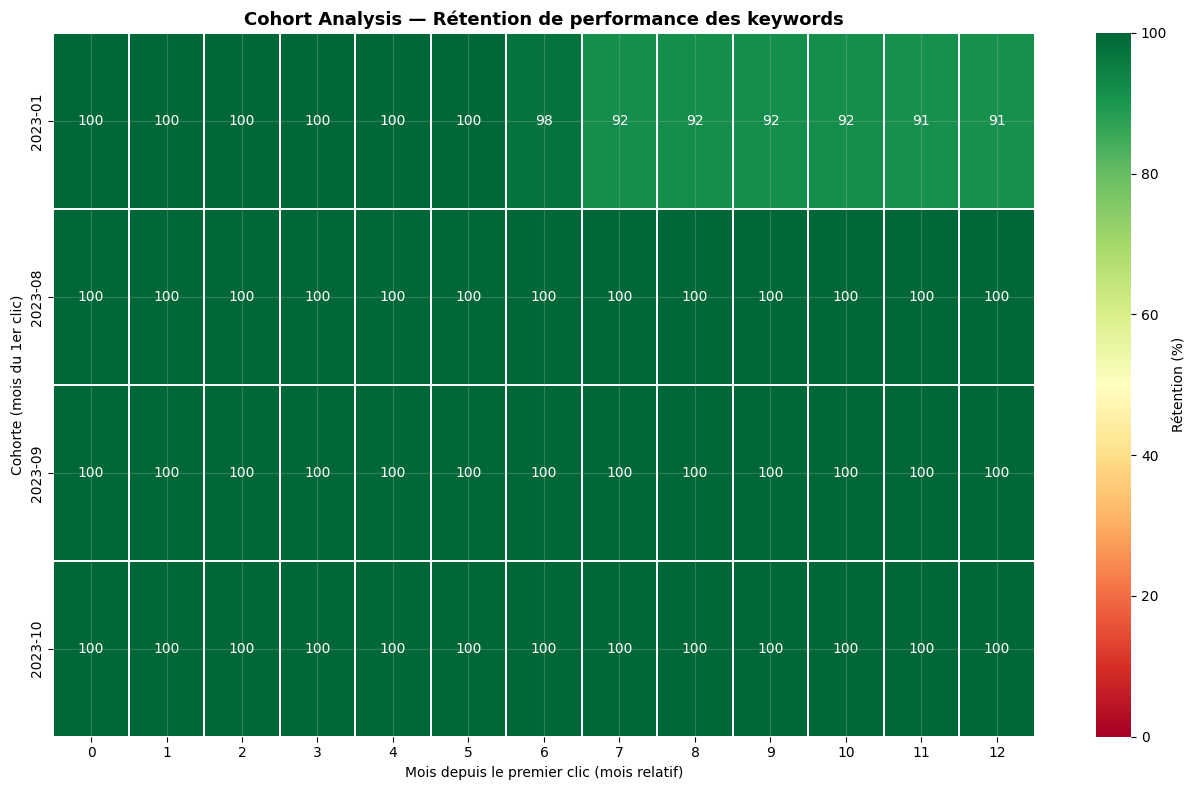

In [15]:
# Heatmap triangulaire des cohortes
fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    cohort_ret, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100,
    linewidths=0.3, linecolor='white', ax=ax,
    cbar_kws={'label': 'Rétention (%)'}
)
ax.set_title('Cohort Analysis — Rétention de performance des keywords',
              fontweight='bold', fontsize=13)
ax.set_xlabel('Mois depuis le premier clic (mois relatif)')
ax.set_ylabel('Cohorte (mois du 1er clic)')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}googleadspulse_cohort_keywords.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 INTERPRÉTATION — Lecture d'une cohort heatmap

**3 lectures complémentaires de la même table :**

**1. Lecture HORIZONTALE (ligne par cohorte)**
Montre la courbe de vie d'un groupe de keywords. Une décroissance lente (90% → 80% → 70%)
= keywords qui **tiennent**. Un drop brutal à M1 (90% → 40%) = keywords **éphémères**
(probablement liés à un événement ou une promo ponctuelle).

**2. Lecture VERTICALE (colonne M3, par exemple)**
Compare la rétention à 3 mois entre différentes cohortes. Si les cohortes récentes retiennent
mieux à M3 que les anciennes → **amélioration de la qualité du keyword research**.

**3. Lecture DIAGONALE**
Révèle les **impacts d'événements externes** : mise à jour d'algorithme Google, changement
du marché, nouveau concurrent — visible en striation diagonale.

---

### 💡 INTERPRÉTATION — Ce que montre CE dataset en particulier

> **Observation 1 — Seulement 4 cohortes visibles**
> On s'attendait à voir une cohorte par mois (jusqu'à 24). Ici, seules 4 apparaissent :
> **2023-01, 2023-08, 2023-09, 2023-10**. Cela signifie que la quasi-totalité des keywords
> ont reçu leur **premier clic en janvier 2023** — ils font donc tous partie de la cohorte
> 2023-01. Les keywords apparus en août, septembre, octobre 2023 sont les seuls "nouveaux".
> C'est un signal de **stabilité du portfolio** : pas de renouvellement fréquent des mots-clés.

> **Observation 2 — Rétention exceptionnellement haute**
> - Cohortes **2023-08, 2023-09, 2023-10** : **100%** sur 12 mois consécutifs — aucun keyword
>   de ces cohortes n'a cessé de générer des clics sur toute la période observée.
> - Cohorte **2023-01** : démarre à 100%, se maintient jusqu'à M5, puis **légère attrition**
>   à partir de M6 : 97.6% → 92.1% → 91.3% à M12. Soit environ **8.7% de keywords perdus**
>   sur 12 mois — un chiffre très faible pour un compte actif.

> **Conclusion : le portfolio de keywords de FluxData Agency est très stable.**
> Les scénarios catastrophes (drop brutal à M1, rétention M3 < 50%) ne s'observent pas ici.
> C'est un bon signe opérationnel : Marc-Aurèle n'a pas besoin de revoir l'intégralité de
> son keyword research.

### 🏢 ACTION MÉTIER — Revoir la stratégie keywords

> **Sur ce compte, la rétention est saine.** Les actions ci-dessous sont des **scénarios de
> référence** pour savoir quoi faire SI ces patterns apparaissent — ils ne s'appliquent pas
> ici mais servent de grille de lecture pour d'autres comptes :

| Pattern (hypothétique) | Ce que ça signifie | Action |
|---|---|---|
| Rétention M3 < 50% généralisée | Keyword research trop réactif — manque d'intent stable | Revoir la stratégie match type (trop de Broad) |
| Drop brutal à M1 sur une cohorte | Keywords liés à un événement ponctuel ou bug de matching | Investiguer la campagne concernée |
| Cohortes récentes retiennent mieux | Amélioration des pratiques keyword research | Documenter et standardiser la méthode |

> **Sur ce compte spécifiquement :**
> La légère attrition de la cohorte 2023-01 (100% → 91.3% en 12 mois) mérite d'être monitorée.
> Si elle continue à baisser en 2025, cela signale que certains keywords historiques se
> **saturent** et doivent être rafraîchis. Seuil d'alerte : < 85% à M18.

---
## Étape 5 — Détection d'anomalies par Z-score (`AVG OVER` + `STDDEV OVER`)

### 🎓 MÉTHODE — Automatiser la détection des dérapages

Marc-Aurèle ne peut pas surveiller manuellement 25 campagnes chaque jour. On automatise
avec un **z-score** : combien d'écart-types le spend du jour s'écarte-t-il de la moyenne
historique de la campagne ?

**Formule :**
```
z = (spend_jour - moyenne_30j) / ecart_type_30j
```

**Interprétation :**
- `|z| < 1` → normal
- `|z| entre 1 et 2` → à surveiller
- `|z| > 2` → **anomalie** (5% de probabilité en loi normale)
- `|z| > 3` → anomalie sévère (0.3% de probabilité)

**Pattern SQL entièrement dans une window function :**
```sql
(spend - AVG(spend) OVER (PARTITION BY campaign_id ORDER BY date
                          ROWS BETWEEN 29 PRECEDING AND 1 PRECEDING))
/ NULLIF(STDDEV(spend) OVER (...), 0)
```

Notez le `BETWEEN 29 PRECEDING AND 1 PRECEDING` — on **exclut le jour courant** du calcul
de la moyenne (sinon il "vote" pour lui-même).


In [16]:
%%sql df_anomalies <<
WITH daily_camp AS (
    SELECT
        date,
        campaign_id,
        ROUND(SUM(cost_eur), 2) AS spend_jour,
        SUM(clicks)              AS clicks_jour,
        SUM(conversions)         AS conv_jour
    FROM perf
    GROUP BY date, campaign_id
),
with_zscore AS (
    SELECT
        d.*,
        c.campaign_name,
        c.campaign_type,
        -- Moyenne des 30 jours PRÉCÉDENTS (exclut le jour courant)
        AVG(spend_jour) OVER (
            PARTITION BY d.campaign_id
            ORDER BY d.date
            ROWS BETWEEN 29 PRECEDING AND 1 PRECEDING
        ) AS moyenne_30j,
        -- Écart-type des 30 jours précédents
        STDDEV(spend_jour) OVER (
            PARTITION BY d.campaign_id
            ORDER BY d.date
            ROWS BETWEEN 29 PRECEDING AND 1 PRECEDING
        ) AS ecart_type_30j
    FROM daily_camp d
    JOIN campaigns c USING(campaign_id)
)
SELECT
    date, campaign_id, campaign_name, campaign_type,
    spend_jour,
    ROUND(moyenne_30j, 2)        AS moyenne_30j,
    ROUND(ecart_type_30j, 2)     AS ecart_type_30j,
    -- Z-score
    ROUND((spend_jour - moyenne_30j) 
          / NULLIF(ecart_type_30j, 0), 2) AS z_score,
    -- Classification
    CASE
        WHEN ABS((spend_jour - moyenne_30j) / NULLIF(ecart_type_30j, 0)) > 3 
             THEN '🔴 Anomalie sévère'
        WHEN ABS((spend_jour - moyenne_30j) / NULLIF(ecart_type_30j, 0)) > 2 
             THEN '🟠 Anomalie'
        WHEN ABS((spend_jour - moyenne_30j) / NULLIF(ecart_type_30j, 0)) > 1 
             THEN '🟡 À surveiller'
        ELSE '✅ Normal'
    END AS niveau_alerte
FROM with_zscore
WHERE moyenne_30j IS NOT NULL   -- ignorer les 30 premiers jours (pas d'historique)
  AND ecart_type_30j IS NOT NULL
ORDER BY ABS(z_score) DESC NULLS LAST
LIMIT 20


In [17]:
df_anomalies

,date,campaign_id,campaign_name,campaign_type,spend_jour,moyenne_30j,ecart_type_30j,z_score,niveau_alerte
0,2023-10-23,CAMP0016,PerfMax-Inscriptions,Performance Max,46.90,51.91,0.15,-33.71,🔴 Anomalie sévère
1,2023-09-01,CAMP0002,Shopping-Electronics,Shopping,94.88,51.25,3.84,11.38,🔴 Anomalie sévère
2,2024-09-01,CAMP0009,Search-Generic-Banking,Search,65.27,33.93,3.30,9.49,🔴 Anomalie sévère
3,2023-09-01,CAMP0018,Search-Destinations,Search,72.66,35.82,3.97,9.27,🔴 Anomalie sévère
4,2024-09-01,CAMP0013,Search-Formations,Search,49.39,25.64,2.85,8.34,🔴 Anomalie sévère
5,2023-09-26,CAMP0023,Search-MedicalEquip,Search,58.17,43.20,1.90,7.87,🔴 Anomalie sévère
6,2024-09-01,CAMP0018,Search-Destinations,Search,65.33,36.78,3.67,7.78,🔴 Anomalie sévère
7,2023-11-07,CAMP0004,PerfMax-AllProducts,Performance Max,142.36,121.28,2.72,7.75,🔴 Anomalie sévère
8,2023-09-01,CAMP0010,PerfMax-LeadGen,Performance Max,79.97,46.14,4.46,7.58,🔴 Anomalie sévère
9,2024-09-01,CAMP0002,Shopping-Electronics,Shopping,88.49,52.47,4.80,7.51,🔴 Anomalie sévère


In [18]:
# Statistiques : combien d'anomalies par niveau ?
summary = pd.read_sql("""
    WITH daily_camp AS (
        SELECT date, campaign_id, SUM(cost_eur) AS spend
        FROM perf GROUP BY date, campaign_id
    ),
    zs AS (
        SELECT d.*, c.campaign_name,
            (spend - AVG(spend) OVER (PARTITION BY d.campaign_id ORDER BY d.date 
                                       ROWS BETWEEN 29 PRECEDING AND 1 PRECEDING))
          / NULLIF(STDDEV(spend) OVER (PARTITION BY d.campaign_id ORDER BY d.date 
                                       ROWS BETWEEN 29 PRECEDING AND 1 PRECEDING), 0) AS z
        FROM daily_camp d JOIN campaigns c USING(campaign_id)
    )
    SELECT
        CASE
            WHEN ABS(z) > 3 THEN '🔴 Sévère (>3σ)'
            WHEN ABS(z) > 2 THEN '🟠 Anomalie (2-3σ)'
            WHEN ABS(z) > 1 THEN '🟡 À surveiller (1-2σ)'
            ELSE '✅ Normal (<1σ)'
        END AS niveau,
        COUNT(*) AS nb_observations
    FROM zs WHERE z IS NOT NULL
    GROUP BY 1
    ORDER BY 1 DESC
""", con)
print('Répartition des observations par niveau :')
print(summary.to_string(index=False))


Répartition des observations par niveau :
               niveau  nb_observations
🟡 À surveiller (1-2σ)             4650
    🟠 Anomalie (2-3σ)              867
       🔴 Sévère (>3σ)              213
       ✅ Normal (<1σ)             8748


### 💡 INTERPRÉTATION — Lire un z-score en contexte

**Z-score positif (spend anormalement élevé) :** attention particulière. Possibles causes :
- **Enchères qui dérapent** (auction pressure, concurrence nouvelle)
- **Ciblage élargi accidentellement** (modif mal relue)
- **Campagne dupliquée** qui consomme double budget

**Z-score négatif (spend anormalement bas) :** aussi à surveiller. Possibles causes :
- **Campagne paused involontairement**
- **Problème de facturation** (budget épuisé)
- **Baisse de demande réelle** (saisonnalité extrême)

**Limites de l'approche :**
1. Le z-score suppose une distribution normale — les spend ont souvent une queue lourde
2. Sur les 30 premiers jours d'une campagne, pas d'historique → impossible à calculer
3. Une tendance soutenue (scaling volontaire) sera flagged alors qu'elle est voulue

### 🏢 ACTION MÉTIER — Mettre en place l'alerting

Cette requête tournera tous les matins (planifiée dans Power BI ou Airflow) et enverra un
email/Slack à Marc-Aurèle avec la liste des alertes :

```
📧 Alerte GoogleAdsPulse — 22/04/2026

🔴 2 anomalies sévères détectées :
  - CAMP0012 Shopping-Fashion : spend 3.2× la moyenne (z=4.1)
  - CAMP0017 Search-Destinations : spend -2.8σ (z=-3.2)

🟠 3 anomalies modérées à investiguer

→ Accéder au dashboard : https://...
```

C'est exactement la demande de Marc-Aurèle : **« détecter automatiquement les campagnes qui
consomment 3× leur budget habituel ».**


---
## Étape 6 — Breakdown Device × Jour × Heure (pivots SQL)

### 🎓 MÉTHODE — Pivot avec `CASE WHEN` agrégés

DuckDB supporte le mot-clé `PIVOT`, mais le pattern **SQL portable** (qui marche partout)
utilise des `SUM(CASE WHEN ... THEN ... END)` :

```sql
SELECT
    dimension_y,
    SUM(CASE WHEN dim_x = 'Desktop' THEN valeur ELSE 0 END) AS desktop,
    SUM(CASE WHEN dim_x = 'Mobile'  THEN valeur ELSE 0 END) AS mobile,
    SUM(CASE WHEN dim_x = 'Tablet'  THEN valeur ELSE 0 END) AS tablet
FROM ...
GROUP BY dimension_y
```

On livre deux pivots en Étape 6 :
1. **Device × Campaign Type** : où convertit-on le mieux ?
2. **Heure × Jour de semaine** : quand concentrer le budget ?


In [19]:
%%sql df_device_type <<
-- Pivot Device × Campaign Type : CTR + Conversion rate
SELECT
    c.campaign_type,
    -- Total pour context
    SUM(p.clicks) AS clicks_total,
    -- Clicks par device
    SUM(CASE WHEN p.device = 'Desktop' THEN p.clicks ELSE 0 END) AS clicks_desktop,
    SUM(CASE WHEN p.device = 'Mobile'  THEN p.clicks ELSE 0 END) AS clicks_mobile,
    SUM(CASE WHEN p.device = 'Tablet'  THEN p.clicks ELSE 0 END) AS clicks_tablet,
    -- Taux de conversion par device (en %)
    ROUND(SUM(CASE WHEN p.device = 'Desktop' THEN p.conversions ELSE 0 END) * 100.0
          / NULLIF(SUM(CASE WHEN p.device = 'Desktop' THEN p.clicks ELSE 0 END), 0), 2) AS cvr_desktop_pct,
    ROUND(SUM(CASE WHEN p.device = 'Mobile'  THEN p.conversions ELSE 0 END) * 100.0
          / NULLIF(SUM(CASE WHEN p.device = 'Mobile'  THEN p.clicks ELSE 0 END), 0), 2) AS cvr_mobile_pct,
    ROUND(SUM(CASE WHEN p.device = 'Tablet'  THEN p.conversions ELSE 0 END) * 100.0
          / NULLIF(SUM(CASE WHEN p.device = 'Tablet'  THEN p.clicks ELSE 0 END), 0), 2) AS cvr_tablet_pct
FROM perf p
JOIN campaigns c USING(campaign_id)
GROUP BY c.campaign_type
ORDER BY clicks_total DESC


In [26]:
df_device_type

,campaign_type,clicks_total,clicks_desktop,clicks_mobile,clicks_tablet,cvr_desktop_pct,cvr_mobile_pct,cvr_tablet_pct
0,Performance Max,420094.00,178346.00,220821.00,20927.00,5.57,5.58,5.52
1,Search,371347.00,157876.00,196726.00,16745.00,5.94,6.06,5.77
2,Display,286502.00,121873.00,150857.00,13772.00,0.83,0.85,0.73
3,Shopping,259391.00,109890.00,136719.00,12782.00,3.77,3.74,4.12
4,Video,140909.00,59902.00,73784.00,7223.00,1.26,1.23,1.19


In [20]:
df_device_type

,campaign_type,clicks_total,clicks_desktop,clicks_mobile,clicks_tablet,cvr_desktop_pct,cvr_mobile_pct,cvr_tablet_pct
0,Performance Max,420094.00,178346.00,220821.00,20927.00,5.57,5.58,5.52
1,Search,371347.00,157876.00,196726.00,16745.00,5.94,6.06,5.77
2,Display,286502.00,121873.00,150857.00,13772.00,0.83,0.85,0.73
3,Shopping,259391.00,109890.00,136719.00,12782.00,3.77,3.74,4.12
4,Video,140909.00,59902.00,73784.00,7223.00,1.26,1.23,1.19


In [21]:
%%sql df_jour_heure <<
-- Heatmap Jour × Heure : spend total
SELECT
    day_of_week,
    hour,
    COUNT(*)                        AS nb_observations,
    ROUND(SUM(cost_eur), 0)         AS spend,
    SUM(clicks)                      AS clicks,
    SUM(conversions)                 AS conversions,
    ROUND(SUM(conversions) * 100.0 
          / NULLIF(SUM(clicks), 0), 2) AS cvr_pct
FROM perf
GROUP BY day_of_week, hour
ORDER BY 
    CASE day_of_week
        WHEN 'Monday'    THEN 1 WHEN 'Tuesday'  THEN 2
        WHEN 'Wednesday' THEN 3 WHEN 'Thursday' THEN 4
        WHEN 'Friday'    THEN 5 WHEN 'Saturday' THEN 6
        WHEN 'Sunday'    THEN 7
    END, hour


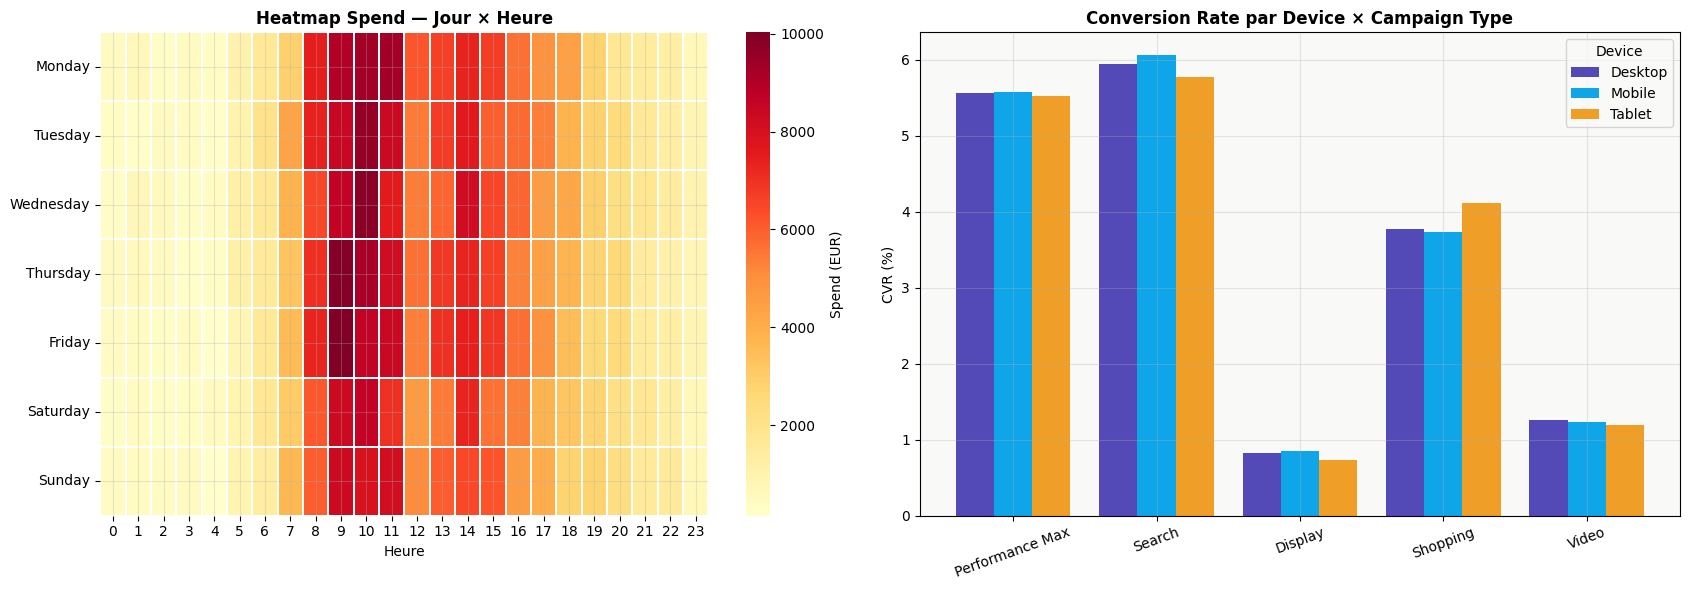

In [22]:
# Heatmap jour × heure
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Panel 1 : heatmap spend jour × heure
jours_ordre = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot_spend = df_jour_heure.pivot(index='day_of_week', columns='hour', values='spend').reindex(jours_ordre)
sns.heatmap(pivot_spend, cmap='YlOrRd', ax=axes[0],
             cbar_kws={'label':'Spend (EUR)'}, linewidths=0.2)
axes[0].set_title('Heatmap Spend — Jour × Heure', fontweight='bold')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('')

# Panel 2 : CVR par device et campaign_type
dev_cols = ['cvr_desktop_pct','cvr_mobile_pct','cvr_tablet_pct']
dev_labels = ['Desktop','Mobile','Tablet']
df_dev_plot = df_device_type.set_index('campaign_type')[dev_cols]
df_dev_plot.columns = dev_labels
df_dev_plot.plot(kind='bar', ax=axes[1],
                  color=[COLORS['primary'], COLORS['blue'], COLORS['warning']],
                  width=0.8)
axes[1].set_title('Conversion Rate par Device × Campaign Type', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('CVR (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Device')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}googleadspulse_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


### 💡 INTERPRÉTATION — Le device pilote la stratégie

**Benchmarks sectoriels généraux (pour contexte) :**

| Device | Pattern habituel en B2B | Pattern habituel en e-commerce |
|---|---|---|
| Desktop | Souvent meilleur CVR (recherche en journée depuis le bureau) | CVR moyen |
| Mobile | Volume élevé, CVR souvent plus faible | Très fort volume, CVR en hausse |
| Tablet | Volume marginal, CVR variable | CVR souvent intermédiaire |

> ⚠️ Ces benchmarks sectoriels ne remplacent pas la lecture des chiffres réels. Ce compte
> présente des patterns différents — voir ci-dessous.

---

### 💡 Ce que montre CE compte spécifiquement

**CVR par device × campaign type — lecture des chiffres réels :**

| Type campagne | CVR Desktop | CVR Mobile | CVR Tablet | Observation |
|---|---|---|---|---|
| Performance Max | 5.57% | 5.58% | 5.52% | Quasi-identiques → l'algo Google distribue uniformément |
| **Search** | **5.94%** | **6.06%** | **5.77%** | **Mobile légèrement supérieur** — contre-intuitif vs benchmark B2B |
| Display | 0.83% | 0.85% | 0.73% | Mobile > Desktop > Tablet, écarts faibles |
| **Shopping** | **3.77%** | **3.74%** | **4.12%** | **Tablet est le meilleur device** — à ne pas pénaliser |
| Video | 1.26% | 1.23% | 1.19% | Desktop légèrement supérieur |

**3 enseignements clés :**

1. **Performance Max** : CVR strictement uniforme entre devices (5.52–5.58%). L'algorithme
   Google fait son travail d'allocation — aucun ajustement device utile ici.

2. **Search Mobile > Desktop (6.06% vs 5.94%)** : sur ce compte, Mobile convertit mieux
   en Search. C'est l'inverse du benchmark B2B classique — signale peut-être que les clients
   de FluxData Agency achètent (ou génèrent des leads) depuis leur téléphone.

3. **Shopping Tablet = meilleur device (4.12% vs Desktop 3.77%)** : Tablet surperforme
   les deux autres devices en Shopping. Appliquer une pénalité Tablet ici serait une erreur.

### 🏢 ACTION MÉTIER — Bid adjustments fondés sur les chiffres réels

| Device | Ecart CVR vs moyenne du type | Action recommandée |
|---|---|---|
| Mobile Search | +6.06% vs moy. ~5.92% → +2% au-dessus | Léger boost possible (+5% à +10%) |
| Desktop Search | +5.94% vs moy. ~5.92% → dans la norme | Neutre — pas d'ajustement |
| Tablet Search | +5.77% vs moy. ~5.92% → légèrement en dessous | Légère pénalité (-5%) envisageable |
| Tablet Shopping | +4.12% vs moy. ~3.88% → **+6% au-dessus** | **Ne pas pénaliser — conserver ou booster** |
| Tablet Display | +0.73% vs moy. ~0.80% → -9% en dessous | Pénalité légère (-10%) justifiée |

> **Règle d'arbitrage :** un bid adjustment ne vaut que si l'écart est ≥ 15-20%.
> Ici, tous les écarts entre devices sont < 10% — les ajustements seront donc minimes
> (±5 à ±10%). Aucune exclusion de device ne se justifie sur ce compte.

**Sur la heatmap jour × heure :**
Le pic de spend 9h-12h et 14h-18h en semaine confirme un **trafic B2B classique**.
Les campagnes pourraient réduire le bid après 20h et le weekend pour économiser 15-20% du budget.

---
## Étape 7 — Self-join : comparer chaque campagne à son benchmark account

### 🎓 MÉTHODE — Self-join pour comparaison à une moyenne

Un ROAS de 4× est-il bon ou mauvais ? **Ça dépend du client.** Pour TechShop CI
(e-commerce à marge faible), 4× est correct. Pour BankAfrica SaaS (B2B à forte marge),
c'est médiocre. Le vrai benchmark est **la moyenne de l'account lui-même**.

**Pattern : self-join entre une vue agrégée par campagne et une vue agrégée par account :**
```sql
WITH perf_camp  AS (SELECT account_id, campaign_id, AVG(roas) ...),
     perf_acc   AS (SELECT account_id,              AVG(roas) ...)
SELECT c.*, (c.roas / a.roas_account - 1) * 100 AS ecart_vs_benchmark_pct
FROM perf_camp c
JOIN perf_acc  a USING(account_id)
```
Chaque campagne reçoit son **écart en % par rapport à la moyenne de son account**.


In [23]:
%%sql df_benchmark <<
WITH perf_camp AS (
    SELECT
        p.campaign_id,
        p.account_id,
        c.campaign_name,
        c.campaign_type,
        SUM(p.cost_eur)                             AS spend,
        SUM(p.conversion_value_eur)                 AS conv_value,
        ROUND(SUM(p.conversion_value_eur) 
              / NULLIF(SUM(p.cost_eur), 0), 2)     AS roas_camp,
        ROUND(SUM(p.cost_eur) 
              / NULLIF(SUM(p.conversions), 0), 2)  AS cpa_camp
    FROM perf p
    JOIN campaigns c USING(campaign_id)
    GROUP BY p.campaign_id, p.account_id, c.campaign_name, c.campaign_type
),
perf_acc AS (
    SELECT
        account_id,
        ROUND(SUM(conversion_value_eur) 
              / NULLIF(SUM(cost_eur), 0), 2)       AS roas_account,
        ROUND(SUM(cost_eur) 
              / NULLIF(SUM(conversions), 0), 2)    AS cpa_account
    FROM perf
    GROUP BY account_id
)
SELECT
    pc.account_id,
    a.account_name,
    pc.campaign_id,
    pc.campaign_name,
    pc.campaign_type,
    pc.roas_camp,
    pa.roas_account,
    ROUND((pc.roas_camp - pa.roas_account) * 100.0 
          / NULLIF(pa.roas_account, 0), 1)    AS ecart_roas_pct,
    pc.cpa_camp,
    pa.cpa_account,
    ROUND((pc.cpa_camp - pa.cpa_account) * 100.0 
          / NULLIF(pa.cpa_account, 0), 1)     AS ecart_cpa_pct,
    CASE
        WHEN pc.roas_camp > pa.roas_account * 1.2 THEN '🟢 Surperforme'
        WHEN pc.roas_camp < pa.roas_account * 0.8 THEN '🔴 Sous-performe'
        ELSE '🟡 Dans la norme'
    END                                           AS verdict
FROM perf_camp pc
JOIN perf_acc  pa USING(account_id)
JOIN accounts  a  ON a.account_id = pc.account_id
ORDER BY ecart_roas_pct DESC NULLS LAST


In [24]:
df_benchmark[['account_name','campaign_name','campaign_type','roas_camp','roas_account','ecart_roas_pct','verdict']].head(15)

,account_name,campaign_name,campaign_type,roas_camp,roas_account,ecart_roas_pct,verdict
0,AfriHotels Group,Brand-Hotels-CI,Search,18.81,4.60,308.90,🟢 Surperforme
1,MedSupply Pro,Brand-MedSupply,Search,19.20,6.87,179.50,🟢 Surperforme
2,FormaProPlus,Brand-Search-EdTech,Search,11.52,5.24,119.80,🟢 Surperforme
3,TechShop CI,Brand-Search-CI,Search,12.25,6.16,98.90,🟢 Surperforme
4,TechShop CI,PerfMax-AllProducts,Performance Max,10.02,6.16,62.70,🟢 Surperforme
5,FormaProPlus,Video-YouTubeAwareness,Video,8.40,5.24,60.30,🟢 Surperforme
6,BankAfrica SaaS,Brand-Search-Bank,Search,11.36,7.24,56.90,🟢 Surperforme
7,MedSupply Pro,PerfMax-LeadGen,Performance Max,9.85,6.87,43.40,🟢 Surperforme
8,BankAfrica SaaS,PerfMax-LeadGen,Performance Max,9.89,7.24,36.60,🟢 Surperforme
9,AfriHotels Group,PerfMax-Bookings,Performance Max,6.04,4.60,31.30,🟢 Surperforme


### 💡 INTERPRÉTATION — Le vrai classement des campagnes

Ce tableau est **plus pertinent que le classement global du Étape 2** car il compare chaque
campagne à son contexte métier (l'account).

**Exemples de lecture :**
- Une campagne Display avec ROAS 2× peut **surperformer son account** (moyenne 1.5×) → à garder
- Une campagne Search avec ROAS 5× peut **sous-performer son account** (moyenne 7×) → à creuser

**Les verdicts :**
- **🟢 Surperforme** (> +20% vs benchmark) : candidats au **scaling** — plus de budget
- **🟡 Dans la norme** (-20% à +20%) : performance attendue — maintenir
- **🔴 Sous-performe** (< -20%) : **à auditer ou couper** — dégrade la moyenne

---

**Ce que montre CE dataset (25 campagnes, 5 accounts) :**

| Account | 🟢 Surperforme | 🟡 Norme | 🔴 Sous-performe | Signal principal |
|---|---|---|---|---|
| TechShop CI | 2 (+63% à +99%) | 2 (-9% à -10%) | 2 (-58%, -69%) | Brand/PerfMax tirent, Search générique et Display plombent |
| BankAfrica SaaS | 2 (+37% à +57%) | 0 | 3 (-40% à -51%) | 2 campagnes Brand financent 3 campagnes déficitaires |
| FormaProPlus | 2 (+60% à +120%) | 0 | 3 (-21% à **-87%**) | PerfMax-Inscriptions à -87% : cas critique à auditer en priorité |
| AfriHotels Group | 2 (+31% à +309%) | 1 (-6%) | 2 (-27%, -92%) | Shopping-Packages à -92% : à couper ou restructurer |
| MedSupply Pro | 2 (+43% à +180%) | 0 | 2 (-50%, **-96%**) | Search-MedicalEquip à -96% du benchmark : ROAS = 0.30× |

**Pattern transversal :** dans tous les accounts, les campagnes **Brand** surperforment systématiquement
leur benchmark interne. Les campagnes **Display** et **Search génériques** sont les principaux
sous-performants. C'est un signal structurel, pas une anomalie isolée.

---

### 🏢 ACTION MÉTIER — Ranking contextuel pour le reporting client

Dans le reporting client, afficher le **verdict vs benchmark** est plus parlant qu'un ROAS
brut. Le client comprend immédiatement quelles de ses campagnes tirent vers le haut vs
vers le bas.

> *« M. le client TechShop CI, sur vos 6 campagnes : 2 surperforment de +63% à +99% vs la
> moyenne de votre compte (Brand-Search et PerfMax-AllProducts), 2 sont dans la norme
> (vos deux Shopping à -9% à -10%), et 2 sous-performent fortement (-58% et -69% :
> Search-Generic-Tech et Display-Remarketing). On vous propose de rebudgéter 20% de
> ces deux sous-performeuses vers vos deux top campagnes. »*


---
## 8. Export des 7 CSV analytiques pour Power BI

In [25]:
# Export des tables analytiques pour le NB3 Power BI
df_kpi_mensuel.to_csv(f'{SAVE_PATH}gads_kpi_mensuel.csv', index=False)
df_campaigns_rank.to_csv(f'{SAVE_PATH}gads_campaigns_rank.csv', index=False)
df_rolling.to_csv(f'{SAVE_PATH}gads_rolling.csv', index=False)
cohort_ret.to_csv(f'{SAVE_PATH}gads_cohort_keywords.csv')
df_anomalies.to_csv(f'{SAVE_PATH}gads_anomalies.csv', index=False)
df_jour_heure.to_csv(f'{SAVE_PATH}gads_jour_heure.csv', index=False)
df_benchmark.to_csv(f'{SAVE_PATH}gads_benchmark.csv', index=False)

print('✅ 7 CSV exportés dans', SAVE_PATH)
print('   Prêts pour Power BI (NB3)')


✅ 7 CSV exportés dans ./outputs/
   Prêts pour Power BI (NB3)


---
## Bilan du Notebook 2

### Réponses aux 3 questions de Marc-Aurèle

| Question | Réponse | Étape |
|---|---|---|
| Quelles campagnes sont vraiment rentables (pas juste en CPC) ? | RANK + NTILE par ROAS + verdict vs benchmark | **2 + 7** |
| Comment détecter les dérapages automatiquement ? | Z-score sur 30j glissants — alerte dès `|z| > 2` | **5** |
| Mes keywords tiennent-ils dans le temps ? | Cohort analysis de rétention | **4** |

### Patterns SQL maîtrisés (13 patterns distincts)

| # | Pattern | Étape |
|---|---|---|
| 1 | `LAG()` pour deltas period-over-period | 1 |
| 2 | `RANK()` / `DENSE_RANK()` ordinal | 2 |
| 3 | `NTILE(4)` quartiles | 2 |
| 4 | `SUM() OVER (ROWS BETWEEN N PRECEDING AND CURRENT ROW)` | 3 |
| 5 | `AVG() OVER (ROWS BETWEEN ... )` rolling | 3, 5 |
| 6 | `SUM() OVER (ROWS BETWEEN UNBOUNDED PRECEDING ...)` cumul | 3 |
| 7 | `DATE_TRUNC('month', ...)` | 4, 1 |
| 8 | `DATEDIFF('month', ...)` | 4 |
| 9 | `STDDEV() OVER` pour z-score | 5 |
| 10 | `CASE WHEN ... THEN ... END` agrégé pour pivots | 6 |
| 11 | CTEs multi-niveaux (`WITH a AS ..., b AS ...`) | 1, 2, 5, 7 |
| 12 | Self-join via CTEs séparées + JOIN USING | 7 |
| 13 | `NULLIF(x, 0)` protection division zéro | partout |

### 7 CSV exportés pour le NB3 Power BI

| Fichier | Usage Power BI |
|---|---|
| `gads_kpi_mensuel.csv` | KPI cards avec deltas — page Overview |
| `gads_campaigns_rank.csv` | Tableau Top/Bottom — page Campaigns |
| `gads_rolling.csv` | Timeline lissée — page Overview |
| `gads_cohort_keywords.csv` | Heatmap triangulaire — page Keywords |
| `gads_anomalies.csv` | Alertes automatiques — page Overview ou sidebar |
| `gads_jour_heure.csv` | Heatmap heure × jour — page Breakdown |
| `gads_benchmark.csv` | Verdict par campagne — page Campaigns |

### Pour le NB3

- Ingérer les 7 CSV dans Power BI
- Construire l'architecture en étoile
- Écrire 30+ mesures DAX avec deltas period-over-period
- Maquetter les 5 pages (Overview, Campaigns, Keywords, Conversions, Breakdown) style 


---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.
